In [1]:
# ============================================================
# CELL 1 — Install & Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2 — Load Raw Data
# ============================================================

# If running on Colab, upload the file first or mount Drive
# from google.colab import files
# uploaded = files.upload()

df_raw = pd.read_csv("Spaceship Titanic (2).csv")
print(f"Raw data shape: {df_raw.shape}")
df_raw.head()

Raw data shape: (8693, 22)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,GroupId,GroupSize,TotalSpent,HasSpent,AgeGroup,Deck,CabinNum,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,Maham Ofracculy,False,1,1,0.0,0,adult,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,Juanna Vines,True,2,1,736.0,1,young_adult,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,Altark Susent,False,3,2,9058.1,1,middle_age,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,Solam Susent,False,3,2,5176.0,1,young_adult,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,Willy Santantines,True,4,1,1091.0,1,teen,F,1,S


In [3]:
# ============================================================
# CELL 3 — Initial Exploration
# ============================================================

print("=== Data Types & Missing Values ===")
print(df_raw.info())
print("\n=== Missing Values Count ===")
print(df_raw.isnull().sum())
print("\n=== Basic Statistics ===")
df_raw.describe()

=== Data Types & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   object 
 13  Transported   8693 non-null   bool   
 14  GroupId       8693 non-null   int64  
 15  GroupSize     8693 non-null   int64  
 16  TotalSpent    8693 non-null   float64
 17  HasSpent      8693 non-null   int64

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,GroupSize,TotalSpent,HasSpent,CabinNum
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.792937,203.234646,406.533839,150.912159,270.158472,263.743297,4633.389624,2.035546,1268.867821,0.579777,600.454964
std,14.348977,523.850529,1234.425242,398.079089,821.430000,827.314115,2671.028856,1.596347,2002.106695,0.493623,507.996725
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2319.000000,1.000000,0.000000,0.000000,166.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4630.000000,1.000000,716.000000,1.000000,435.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000,6883.000000,3.000000,1441.000000,1.000000,983.000000
max,79.000000,3096.230000,8033.310000,2333.440000,5390.100000,5646.680000,9280.000000,8.000000,10235.568000,1.000000,1894.000000


In [4]:
# ============================================================
# CELL 4 — Data Cleaning
# ============================================================

df = df_raw.copy()

# --- Split Cabin into Deck, CabinNum, Side ---
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

# --- Split PassengerId to extract GroupId ---
df['GroupId'] = df['PassengerId'].str.split('_').str[0]

# --- Spending columns ---
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Fill spending NaN with 0 (CryoSleep passengers spend nothing)
for col in spending_cols:
    df[col] = df[col].fillna(0)

# --- CryoSleep: if spending > 0, must be False ---
df['CryoSleep'] = df['CryoSleep'].fillna(False)
df.loc[df[spending_cols].sum(axis=1) > 0, 'CryoSleep'] = False

# --- Fill categorical NaN with mode ---
for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Fill Age with median ---
df['Age'] = df['Age'].fillna(df['Age'].median())

# --- Fill VIP with mode ---
df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

# --- Encode booleans to int ---
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP']       = df['VIP'].astype(int)

# --- Encode target ---
df['Transported'] = df['Transported'].astype(int)

print(f"Shape after cleaning: {df.shape}")
print("Missing values remaining:", df.isnull().sum().sum())

Shape after cleaning: (8693, 22)
Missing values remaining: 0


In [5]:
# ============================================================
# CELL 5 — Feature Engineering
# ============================================================

# Total spending per passenger
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# Number of services used (out of 5)
df['ServicesUsed'] = (df[spending_cols] > 0).sum(axis=1).astype(int)

# Age group binning
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 17, 35, 60, 200],
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print("New features added: TotalSpending, ServicesUsed, AgeGroup")
df[['TotalSpending', 'ServicesUsed', 'AgeGroup']].head()

New features added: TotalSpending, ServicesUsed, AgeGroup


,TotalSpending,ServicesUsed,AgeGroup
0,0.0,0,Adult
1,736.0,5,YoungAdult
2,9058.1,4,Adult
3,5176.0,4,YoungAdult
4,1091.0,5,Teen


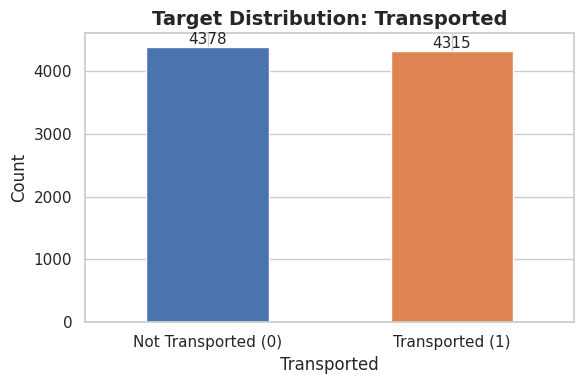

In [6]:
# ============================================================
# CELL 6 — Visualization: Target Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))
df['Transported'].value_counts().plot(kind='bar', ax=ax,
                                       color=['#4C72B0', '#DD8452'],
                                       edgecolor='white')
ax.set_title("Target Distribution: Transported", fontsize=14, fontweight='bold')
ax.set_xticklabels(['Not Transported (0)', 'Transported (1)'], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

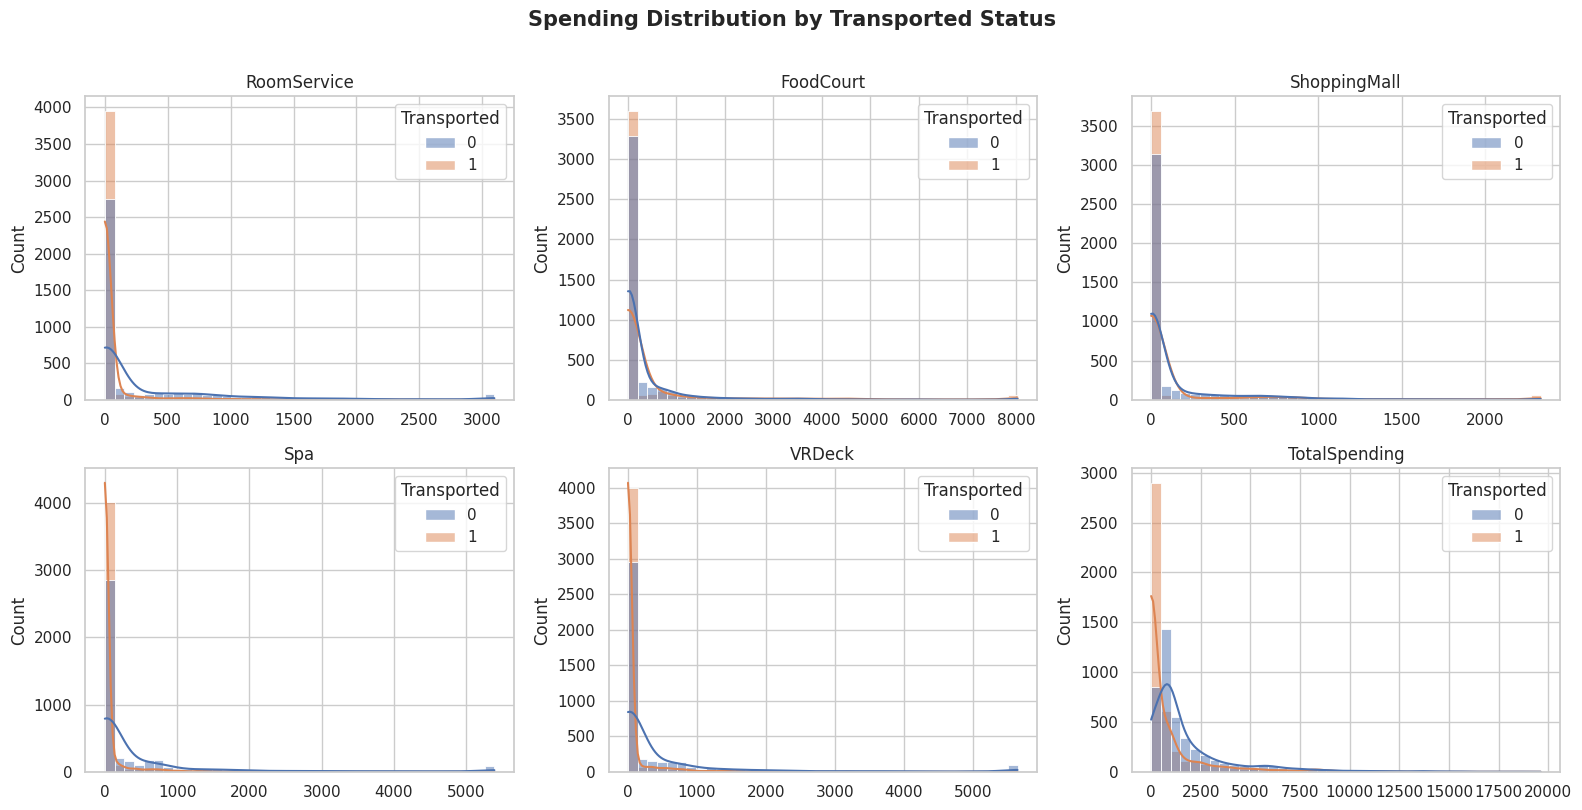

In [7]:
# ============================================================
# CELL 7 — Visualization: Spending Distribution
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(spending_cols + ['TotalSpending']):
    sns.histplot(data=df, x=col, hue='Transported',
                 bins=40, ax=axes[i], kde=True,
                 palette={0: '#4C72B0', 1: '#DD8452'})
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")

plt.suptitle("Spending Distribution by Transported Status", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

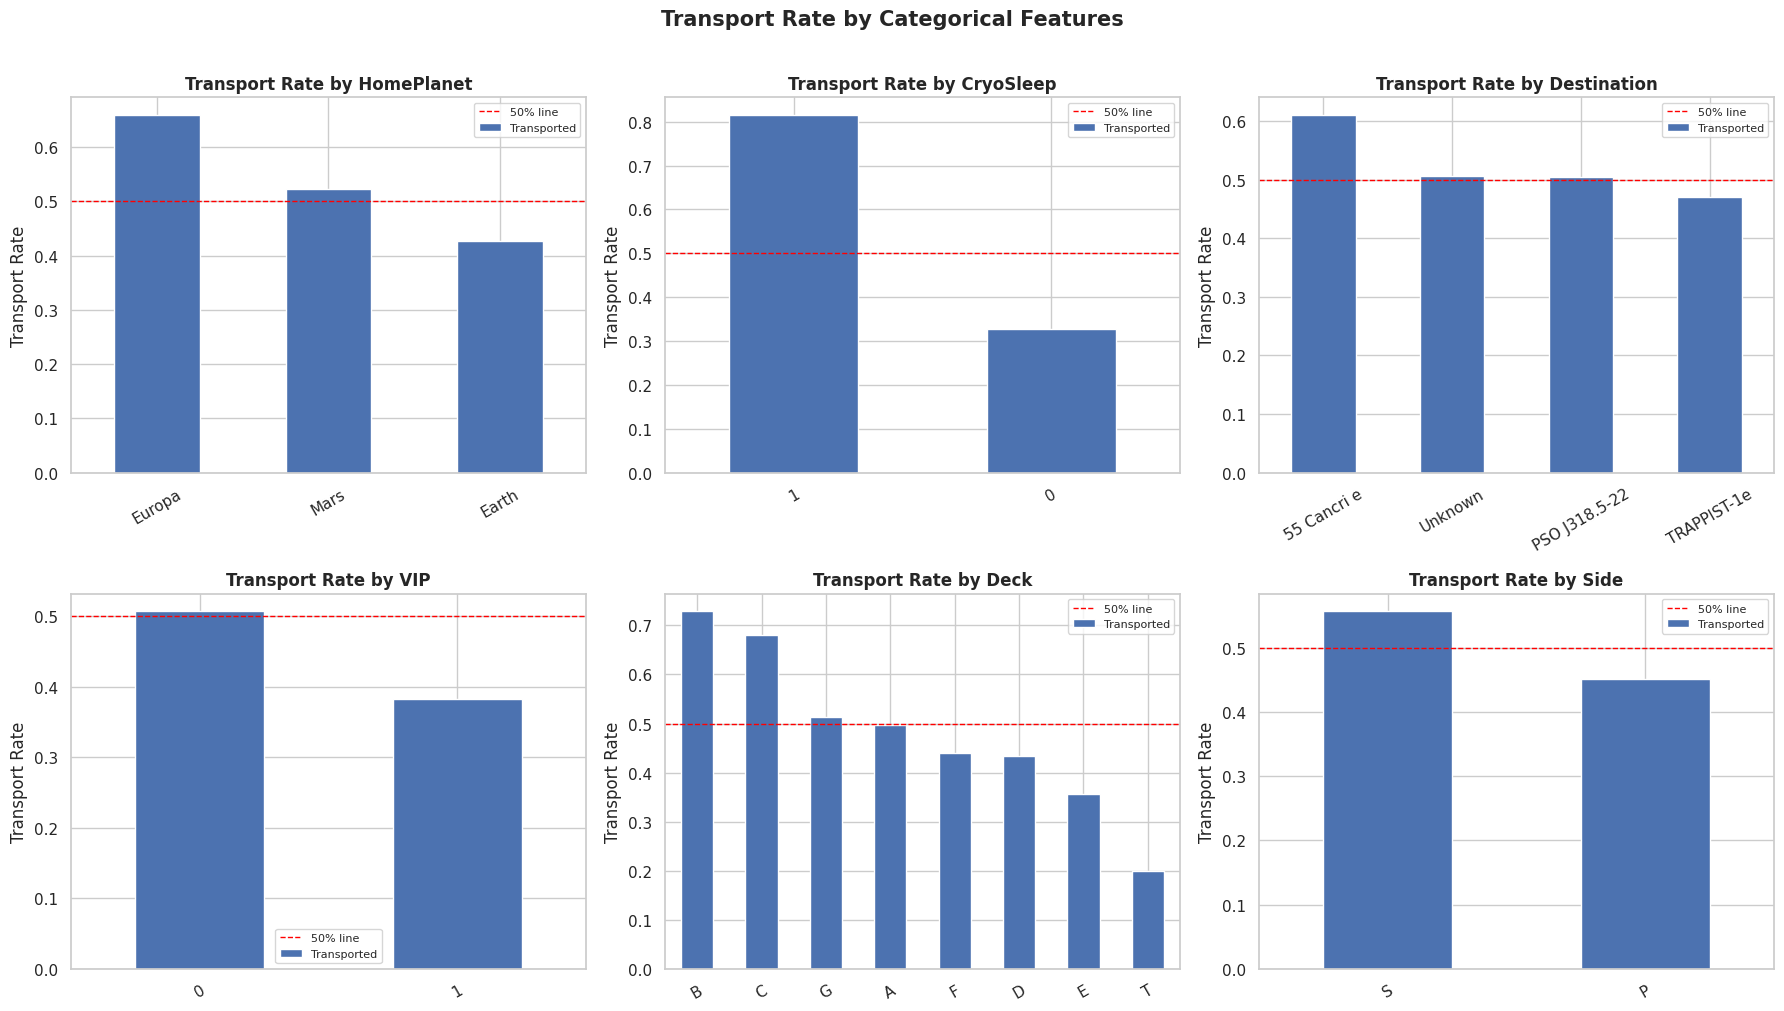

In [8]:
# ============================================================
# CELL 8 — Visualization: Categorical Features vs Target
# ============================================================

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Transported'].mean().sort_values(ascending=False)
    ct.plot(kind='bar', ax=axes[i], color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Transport Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Transport Rate")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
    axes[i].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% line')
    axes[i].legend(fontsize=8)

plt.suptitle("Transport Rate by Categorical Features", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

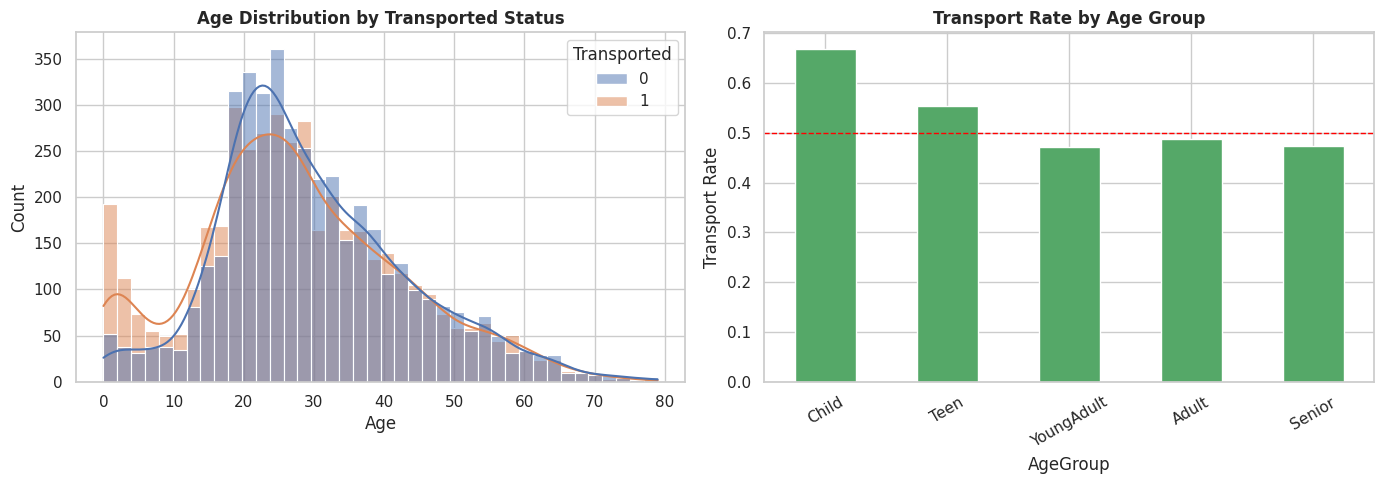

In [9]:
# ============================================================
# CELL 9 — Visualization: Age Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', hue='Transported', bins=40,
             kde=True, ax=axes[0], palette={0: '#4C72B0', 1: '#DD8452'})
axes[0].set_title("Age Distribution by Transported Status", fontweight='bold')

transport_by_age = df.groupby('AgeGroup')['Transported'].mean()
transport_by_age.plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title("Transport Rate by Age Group", fontweight='bold')
axes[1].set_ylabel("Transport Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

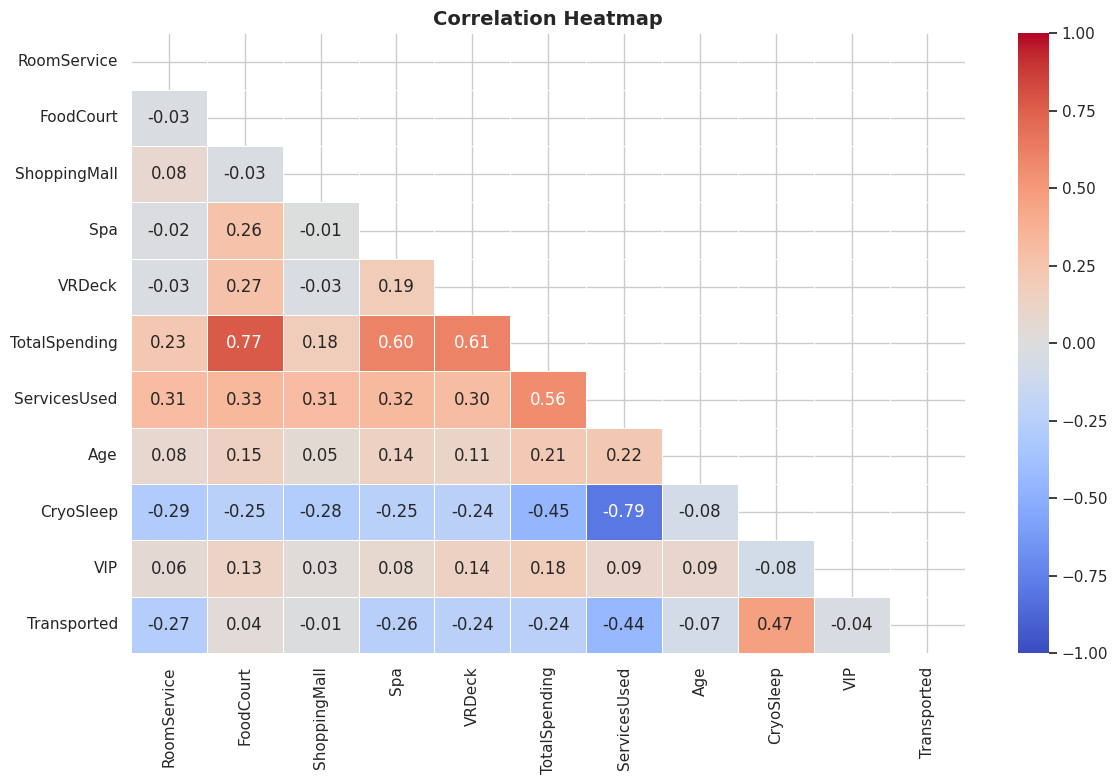

In [10]:
# ============================================================
# CELL 10 — Visualization: Correlation Heatmap
# ============================================================

numeric_df = df[spending_cols + ['TotalSpending', 'ServicesUsed',
                                  'Age', 'CryoSleep', 'VIP', 'Transported']]

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap='coolwarm', mask=mask, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 11 — Prepare Features for Modeling
# ============================================================

df_model = df.copy()

# Drop non-feature columns
df_model.drop(['PassengerId', 'Name', 'Cabin', 'GroupId',
               'CabinNum', 'AgeGroup'], axis=1, inplace=True)

# One-Hot Encode remaining categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

# Convert all bools to int
for col in df_model.columns:
    if df_model[col].dtype == 'bool':
        df_model[col] = df_model[col].astype(int)

df_model = df_model.astype(int)

print(f"Model-ready shape: {df_model.shape}")
print("Missing values:", df_model.isnull().sum().sum())
print("\nFeature columns:")
print([c for c in df_model.columns if c != 'Transported'])

Model-ready shape: (8693, 27)
Missing values: 0

Feature columns:
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpent', 'HasSpent', 'TotalSpending', 'ServicesUsed', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_Unknown', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_S']


In [12]:
# ============================================================
# CELL 12 — Train / Test Split + Scaling
# ============================================================

X = df_model.drop('Transported', axis=1)
y = df_model['Transported']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Train: 6954 samples | Test: 1739 samples
Features: 26


In [13]:
# ============================================================
# CELL 13 — Train Baseline Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                : SVC(kernel='rbf', random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression and SVM
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_prob)
    cv    = cross_val_score(model,
                            X_train_scaled if name in ["Logistic Regression", "SVM"] else X_train,
                            y_train, cv=5, scoring='accuracy').mean()

    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
                     'accuracy': acc, 'auc': auc, 'cv_accuracy': cv}

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  ROC-AUC       : {auc:.4f}")
    print(f"  CV Accuracy   : {cv:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Not Transported','Transported'])}")


  Logistic Regression
  Test Accuracy : 0.7964
  ROC-AUC       : 0.8835
  CV Accuracy   : 0.7898

                 precision    recall  f1-score   support

Not Transported       0.80      0.78      0.79       863
    Transported       0.79      0.81      0.80       876

       accuracy                           0.80      1739
      macro avg       0.80      0.80      0.80      1739
   weighted avg       0.80      0.80      0.80      1739


  Decision Tree
  Test Accuracy : 0.7458
  ROC-AUC       : 0.7657
  CV Accuracy   : 0.7307

                 precision    recall  f1-score   support

Not Transported       0.74      0.75      0.74       863
    Transported       0.75      0.75      0.75       876

       accuracy                           0.75      1739
      macro avg       0.75      0.75      0.75      1739
   weighted avg       0.75      0.75      0.75      1739


  Random Forest
  Test Accuracy : 0.7947
  ROC-AUC       : 0.8775
  CV Accuracy   : 0.7820

                 precisio

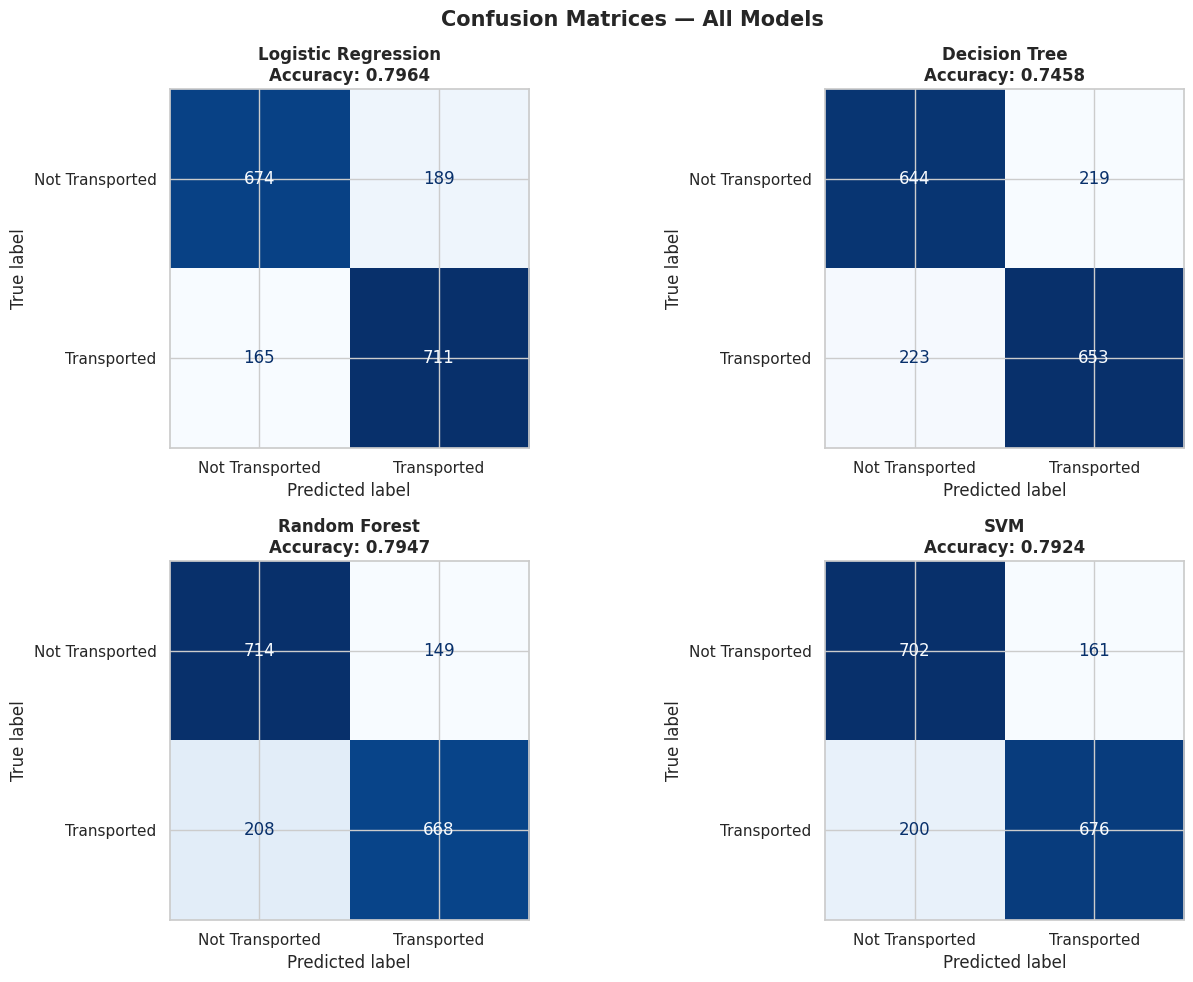

In [14]:
# ============================================================
# CELL 14 — Visualization: Confusion Matrices (All 4 Models)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Transported', 'Transported'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}\nAccuracy: {res['accuracy']:.4f}", fontweight='bold')

plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

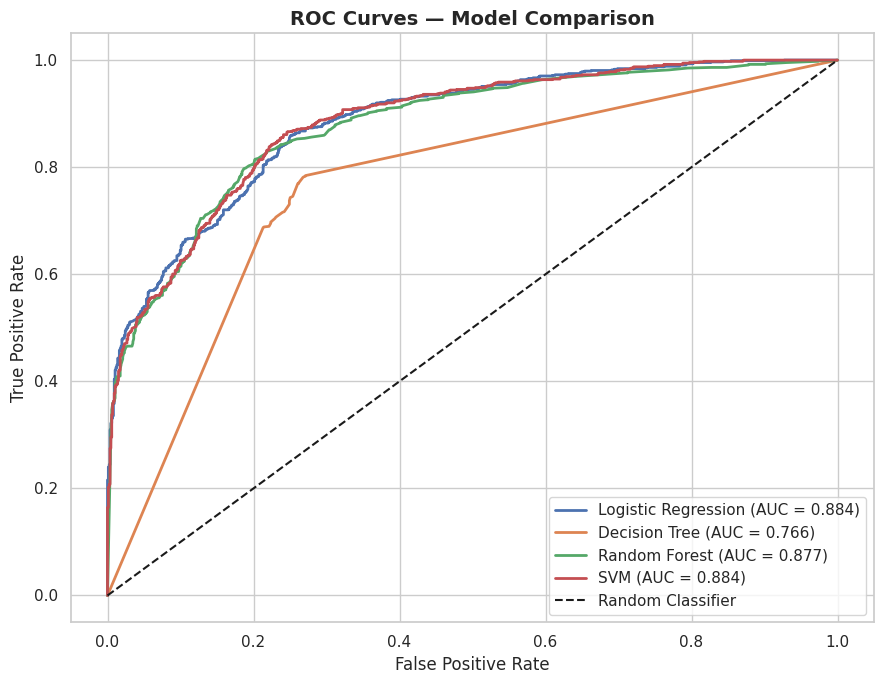

In [15]:
# ============================================================
# CELL 15 — Visualization: ROC Curves (All 4 Models)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Model Comparison", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

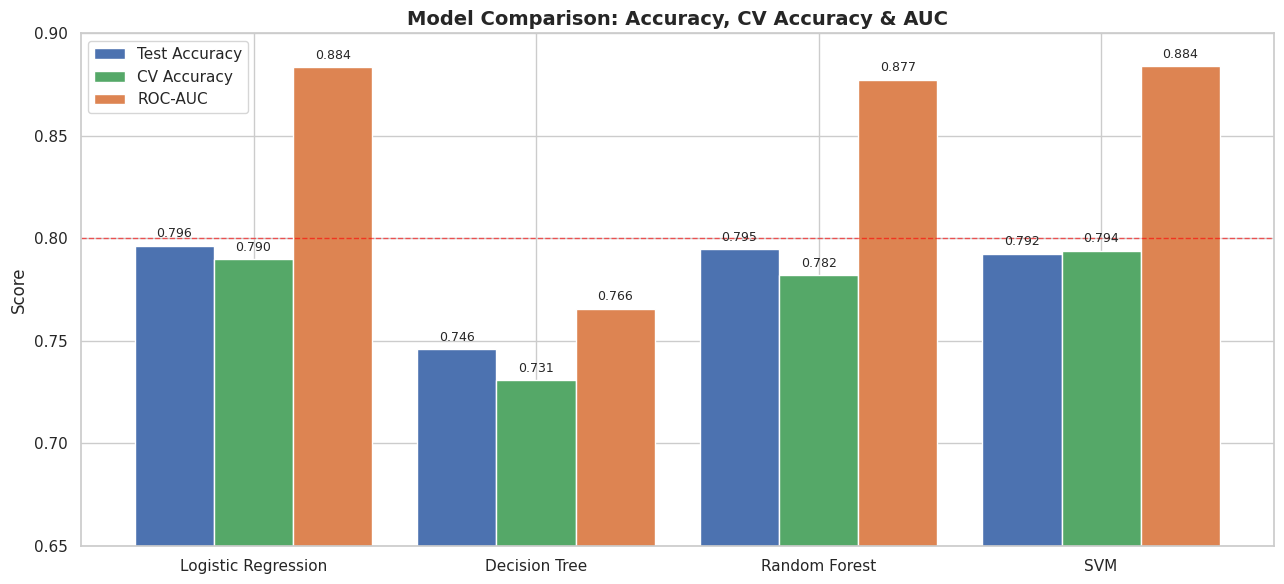

In [16]:
# ============================================================
# CELL 16 — Visualization: Model Accuracy Comparison Bar Chart
# ============================================================

model_names   = list(results.keys())
accuracies    = [results[m]['accuracy']    for m in model_names]
cv_accuracies = [results[m]['cv_accuracy'] for m in model_names]
aucs          = [results[m]['auc']         for m in model_names]

x = np.arange(len(model_names))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, accuracies,    width, label='Test Accuracy', color='#4C72B0')
bars2 = ax.bar(x,         cv_accuracies, width, label='CV Accuracy',   color='#55A868')
bars3 = ax.bar(x + width, aucs,          width, label='ROC-AUC',       color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.65, 0.90)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: Accuracy, CV Accuracy & AUC", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80% line')

for bar in [*bars1, *bars2, *bars3]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 17 — Hyperparameter Tuning (GridSearchCV)
# ============================================================

# --- Random Forest Tuning ---
print("Tuning Random Forest...")
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features' : ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='accuracy',
                       n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params : {rf_grid.best_params_}")
print(f"Best RF CV Acc : {rf_grid.best_score_:.4f}")

# --- SVM Tuning ---
print("\nTuning SVM...")
svm_params = {
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto'],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                        svm_params, cv=5, scoring='accuracy',
                        n_jobs=-1, verbose=0)
svm_grid.fit(X_train_scaled, y_train)
print(f"Best SVM Params : {svm_grid.best_params_}")
print(f"Best SVM CV Acc : {svm_grid.best_score_:.4f}")

Tuning Random Forest...
Best RF Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Acc : 0.7972

Tuning SVM...
Best SVM Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV Acc : 0.7980


In [18]:
# ============================================================
# CELL 18 — Evaluate Tuned Models
# ============================================================

# Tuned Random Forest
best_rf  = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
acc_rf_tuned    = accuracy_score(y_test, y_pred_rf_tuned)
auc_rf_tuned    = roc_auc_score(y_test, y_prob_rf_tuned)

# Tuned SVM
best_svm = svm_grid.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test_scaled)
y_prob_svm_tuned = best_svm.predict_proba(X_test_scaled)[:, 1]
acc_svm_tuned    = accuracy_score(y_test, y_pred_svm_tuned)
auc_svm_tuned    = roc_auc_score(y_test, y_prob_svm_tuned)

print("=== Tuned Model Results ===")
print(f"Tuned Random Forest  — Accuracy: {acc_rf_tuned:.4f}  |  AUC: {auc_rf_tuned:.4f}")
print(f"Tuned SVM            — Accuracy: {acc_svm_tuned:.4f}  |  AUC: {auc_svm_tuned:.4f}")

print("\nClassification Report — Tuned Random Forest:")
print(classification_report(y_test, y_pred_rf_tuned,
                             target_names=['Not Transported','Transported']))

print("\nClassification Report — Tuned SVM:")
print(classification_report(y_test, y_pred_svm_tuned,
                             target_names=['Not Transported','Transported']))

=== Tuned Model Results ===
Tuned Random Forest  — Accuracy: 0.8045  |  AUC: 0.8924
Tuned SVM            — Accuracy: 0.8097  |  AUC: 0.8816

Classification Report — Tuned Random Forest:
                 precision    recall  f1-score   support

Not Transported       0.80      0.80      0.80       863
    Transported       0.81      0.81      0.81       876

       accuracy                           0.80      1739
      macro avg       0.80      0.80      0.80      1739
   weighted avg       0.80      0.80      0.80      1739


Classification Report — Tuned SVM:
                 precision    recall  f1-score   support

Not Transported       0.81      0.80      0.81       863
    Transported       0.81      0.82      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



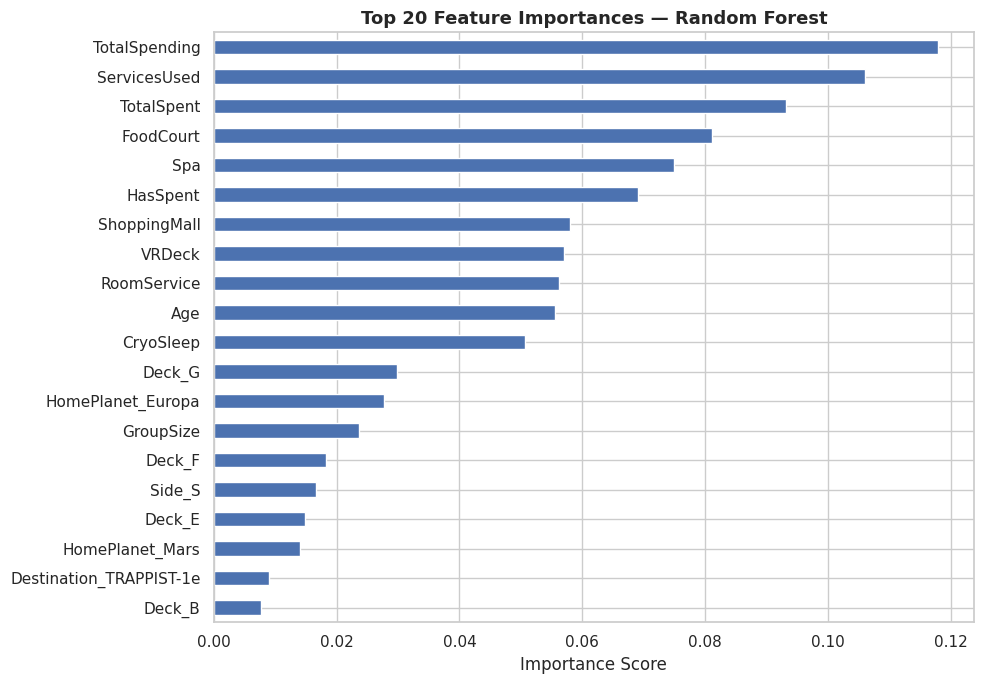

In [19]:
# ============================================================
# CELL 19 — Feature Importance (Tuned Random Forest)
# ============================================================

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 20 — Final Model Selection & Summary
# ============================================================

summary = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'Decision Tree',
                     'Random Forest (Base)', 'SVM (Base)',
                     'Random Forest (Tuned)', 'SVM (Tuned)'],
    'Test Accuracy': [results['Logistic Regression']['accuracy'],
                      results['Decision Tree']['accuracy'],
                      results['Random Forest']['accuracy'],
                      results['SVM']['accuracy'],
                      acc_rf_tuned,
                      acc_svm_tuned],
    'ROC-AUC'     : [results['Logistic Regression']['auc'],
                     results['Decision Tree']['auc'],
                     results['Random Forest']['auc'],
                     results['SVM']['auc'],
                     auc_rf_tuned,
                     auc_svm_tuned]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=== Final Model Summary ===")
print(summary.to_string(index=False))

# Best model = highest accuracy after tuning
best_model_name = summary.iloc[0]['Model']
print(f"\n Best Model Selected: {best_model_name}")

=== Final Model Summary ===
                Model  Test Accuracy  ROC-AUC
          SVM (Tuned)       0.809661 0.881589
Random Forest (Tuned)       0.804485 0.892402
  Logistic Regression       0.796435 0.883521
 Random Forest (Base)       0.794710 0.877454
           SVM (Base)       0.792409 0.883902
        Decision Tree       0.745831 0.765657

 Best Model Selected: SVM (Tuned)


In [21]:
# ============================================================
# CELL 21 — Save Best Model & Scaler for Deployment
# ============================================================

# Save based on which tuned model won
if 'Random Forest' in best_model_name:
    final_model = best_rf
else:
    final_model = best_svm

joblib.dump(final_model, 'best_model.pkl')
joblib.dump(scaler,      'scaler.pkl')

# Save feature names so deployment knows expected input
feature_names = list(X.columns)
joblib.dump(feature_names, 'feature_names.pkl')

print("Files saved for deployment:")
print("  best_model.pkl   — trained model")
print("  scaler.pkl       — fitted StandardScaler")
print("  feature_names.pkl — list of expected feature columns")
print(f"\nModel: {best_model_name}")
print(f"Features used: {len(feature_names)}")

Files saved for deployment:
  best_model.pkl   — trained model
  scaler.pkl       — fitted StandardScaler
  feature_names.pkl — list of expected feature columns

Model: SVM (Tuned)
Features used: 26
